# Интеграция данных

## Цель работы

На практическом примере освоить основные этапы и приемы интеграции разных таблиц данных в единый датасет средствами Python и pandas для последующей подготовки к машинному обучению.

## 1. Загрузка библиотек и первого файла

In [189]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Прочитаем первый из трёх однотипных табличных файлов с данными по обращениям клиентов в службу технической поддержки:

In [190]:
data1 = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.1%20data%20integration/data/issues1.csv",index_col=0)
data1.head()

,Id,Channel,category,Sub-category,Customer Remarks,Order_id,Issue_reported_Date,Issue_responded_Date,Survey_response_Date,Agent_name,CSAT Score
0,8c910188-c387-4a1b-8d90-24379ec8c047,Inbound,Returns,Reverse Pickup Enquiry,Very happy,NaN,04/08/2023 19:10,04/08/2023 19:13,04-Aug-23,J. Blackwell,1
1,99d5ee06-8d2a-4754-bd17-ed235c70bf33,Inbound,Returns,Return request,Thoda jalfi replacement approve kijiye mera,89e6448f-9a48-4892-a09c-b47e0d8a87fe,18/08/2023 09:11,18/08/2023 09:18,18-Aug-23,M. Wilson,4
2,336020c5-dc97-488f-8f16-ed33ed04e5fc,Inbound,Returns,Damaged,Technician not visit the RO and without visit ...,15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6,22/08/2023 07:15,22/08/2023 08:15,22-Aug-23,A. Smith,5
3,22c5643c-3d54-487c-8863-c57e198a70be,Inbound,Returns,Fraudulent User,madam ne mera problem solve kar Diya hai . t...,NaN,14/08/2023 09:21,14/08/2023 09:27,14-Aug-23,A. Berry,5
4,abd330a8-f3e2-4b7a-b14a-4ed35c4ec023,Inbound,Returns,Fraudulent User,Gjjjzjxgxteuhxgxe5xhxh,NaN,03/08/2023 08:18,03/08/2023 08:23,03-Aug-23,S. Taylor,5


Выведем информацию о первой таблице:

In [191]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 28425 entries, 0 to 28424
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Id                    28425 non-null  str  
 1   Channel               28425 non-null  str  
 2   category              28425 non-null  str  
 3   Sub-category          28425 non-null  str  
 4   Customer Remarks      28425 non-null  str  
 5   Order_id              22389 non-null  str  
 6   Issue_reported_Date   28425 non-null  str  
 7   Issue_responded_Date  28425 non-null  str  
 8   Survey_response_Date  28425 non-null  str  
 9   Agent_name            28425 non-null  str  
 10  CSAT Score            28425 non-null  int64
dtypes: int64(1), str(10)
memory usage: 2.4 MB


## 2. Чтение второго и третьего файлов

In [192]:
data2 = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.1%20data%20integration/data/issues2.csv",index_col=0)
data2.head()

,Id,channel_name,category,Sub-category,Order_id,Reported at,Responded at,Survey responded at,Agent_name,CSAT Score
0,6ba211fe-7643-4998-a7f7-cf34e5a4322c,Inbound,Order Related,Delayed,2dab4a7a-baf0-49f9-9d84-c8acdb4a11db,"21 08 2023, 09:01:00 PM","21 08 2023, 09:04:00 PM",21 08 2023,A. Rodriguez,5
1,acef2550-cdd7-4e6a-b5b8-6d9627da9549,Inbound,Cancellation,Not Needed,5993a1f0-570d-4c82-95d9-6cc56c78043e,"18 08 2023, 09:20:00 PM","18 08 2023, 09:20:00 PM",18 08 2023,R. Lee,5
2,46d012ec-cb21-40ce-afe1-5fe78905250a,Inbound,Returns,Return request,b64f579f-d913-4e85-978f-d0f6de902c3f,"24 08 2023, 09:57:00 PM","24 08 2023, 09:58:00 PM",24 08 2023,S. Douglas,5
3,1671c7fa-e527-4a05-8f1f-9a865dad9778,Outcall,Cancellation,Not Needed,b754581f-a2a4-4ef2-abb1-aca09ac1a89c,"28 08 2023, 11:38:00 PM","29 08 2023, 05:55:00 AM",29 08 2023,T. Adams,5
4,6e1923bd-de16-462b-a3ec-c60fb0ffe194,Inbound,Refund Related,Refund Enquiry,a1c40c79-e7a6-4faa-b948-0a32c3e3576a,"30 08 2023, 11:03:00 AM","30 08 2023, 11:04:00 AM",30 08 2023,L. Beck,5


In [193]:
data3 = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.1%20data%20integration/data/issues4.csv",index_col=0)
data3.head()

,Unique id,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Agent,CSAT Score
0,3350ccee-ead7-40fa-80c6-cc7b5e6e345a,Inbound,Returns,Reverse Pickup Enquiry,"August 27, 2023, 08:28:00 AM","August 27, 2023, 08:29:00 AM","August 27, 2023, 12:00:00 AM",Terry Young,5
1,4a88df6e-aafb-477a-bd8e-63ffc34c1a43,Inbound,Returns,Wrong,"December 08, 2023, 03:04:00 PM","August 12, 2023, 03:19:00 PM","August 12, 2023, 12:00:00 AM",Brenda Cox,4
2,7b5dbea2-2370-490a-8fef-4c5f7c52a4cc,Inbound,Returns,Reverse Pickup Enquiry,"August 13, 2023, 12:45:00 PM","August 13, 2023, 01:02:00 PM","August 13, 2023, 12:00:00 AM",Brian Mcguire,5
3,c6d4401e-a4ef-4de0-af68-a8755b928f5f,Inbound,Refund Related,Refund Enquiry,"June 08, 2023, 06:07:00 PM","August 06, 2023, 06:08:00 PM","August 06, 2023, 12:00:00 AM",Dr. Heather Lewis,5
4,423bd17e-e944-4f6e-beff-9c97fa325d9e,Inbound,Returns,Reverse Pickup Enquiry,"April 08, 2023, 10:05:00 PM","August 04, 2023, 10:08:00 PM","August 04, 2023, 12:00:00 AM",Kristin Adams,5


Выведем формы всех трёх таблиц:

In [194]:
data1.shape, data2.shape, data3.shape

((28425, 11), (44339, 10), (13143, 9))

## 3. Подготовка второй таблицы к объединению

Переименуем колонки, чтобы они соответствовали первой таблице:

In [195]:
data2 = data2.rename(columns={
    'channel_name': 'Channel',
    'Reported at': 'Issue_reported_Date',
    'Responded at': 'Issue_responded_Date',
    'Survey responded at': 'Survey_response_Date',
})

Преобразуем даты во второй таблице в формат datetime:

In [196]:
data2['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
data2['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])
data2['Survey_response_Date'] = pd.to_datetime(data2['Survey_response_Date'], format='%d %m %Y')

C:\Users\w1nore\AppData\Local\Temp\ipykernel_16536\1106061918.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
C:\Users\w1nore\AppData\Local\Temp\ipykernel_16536\1106061918.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])


Преобразуем даты в первой таблице:

In [197]:
data1['Issue_reported_Date'] = pd.to_datetime(data1['Issue_reported_Date'], dayfirst=True)
data1['Issue_responded_Date'] = pd.to_datetime(data1['Issue_responded_Date'], dayfirst=True)
data1['Survey_response_Date'] = pd.to_datetime(data1['Survey_response_Date'], format='%d-%b-%y')

## 4. Вертикальная интеграция: объединение 1-й и 2-й таблиц

In [198]:
data_12 = pd.concat([data1, data2])
data_12.head()

,Id,Channel,category,Sub-category,Customer Remarks,Order_id,Issue_reported_Date,Issue_responded_Date,Survey_response_Date,Agent_name,CSAT Score
0,8c910188-c387-4a1b-8d90-24379ec8c047,Inbound,Returns,Reverse Pickup Enquiry,Very happy,NaN,2023-08-04 19:10:00,2023-08-04 19:13:00,2023-08-04,J. Blackwell,1
1,99d5ee06-8d2a-4754-bd17-ed235c70bf33,Inbound,Returns,Return request,Thoda jalfi replacement approve kijiye mera,89e6448f-9a48-4892-a09c-b47e0d8a87fe,2023-08-18 09:11:00,2023-08-18 09:18:00,2023-08-18,M. Wilson,4
2,336020c5-dc97-488f-8f16-ed33ed04e5fc,Inbound,Returns,Damaged,Technician not visit the RO and without visit ...,15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6,2023-08-22 07:15:00,2023-08-22 08:15:00,2023-08-22,A. Smith,5
3,22c5643c-3d54-487c-8863-c57e198a70be,Inbound,Returns,Fraudulent User,madam ne mera problem solve kar Diya hai . t...,NaN,2023-08-14 09:21:00,2023-08-14 09:27:00,2023-08-14,A. Berry,5
4,abd330a8-f3e2-4b7a-b14a-4ed35c4ec023,Inbound,Returns,Fraudulent User,Gjjjzjxgxteuhxgxe5xhxh,NaN,2023-08-03 08:18:00,2023-08-03 08:23:00,2023-08-03,S. Taylor,5


Проверим структуру объединённой таблицы:

In [199]:
data_12.info()

<class 'pandas.DataFrame'>
Index: 72764 entries, 0 to 44338
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    72764 non-null  str           
 1   Channel               72764 non-null  str           
 2   category              72764 non-null  str           
 3   Sub-category          72764 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   72764 non-null  datetime64[us]
 7   Issue_responded_Date  72764 non-null  datetime64[us]
 8   Survey_response_Date  72764 non-null  datetime64[us]
 9   Agent_name            72764 non-null  str           
 10  CSAT Score            72764 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 6.7 MB


## 5. Подготовка и присоединение третьей таблицы

Переименуем колонки в третьей таблице:

In [200]:
data3 = data3.rename(columns={
    'Unique id': 'Id',
    'channel_name': 'Channel',
    'Issue_reported at': 'Issue_reported_Date',
    'issue_responded': 'Issue_responded_Date',
    'Survey responded at': 'Survey_response_Date',
    'Agent': 'Agent_name'
})

Преобразуем даты в третьей таблице:

In [201]:
data3['Issue_reported_Date'] = pd.to_datetime(data3['Issue_reported_Date'])
data3['Issue_responded_Date'] = pd.to_datetime(data3['Issue_responded_Date'])
data3['Survey_response_Date'] = pd.to_datetime(data3['Survey_response_Date'])

C:\Users\w1nore\AppData\Local\Temp\ipykernel_16536\2374507791.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data3['Survey_response_Date'] = pd.to_datetime(data3['Survey_response_Date'])


В третьей таблице имена операторов указаны полностью, а в первых двух — инициалами. Приведём к единому формату (инициалы):

In [202]:
data3['Agent_name'] = data3['Agent_name'].apply(
    lambda x: x.split()[0][0] + ". " + x.split()[1] if isinstance(x, str) else np.NAN
)

Объединяем все три таблицы:

In [203]:
data_123 = pd.concat([data_12, data3])
data_123.info()

<class 'pandas.DataFrame'>
Index: 85907 entries, 0 to 13142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    85907 non-null  str           
 1   Channel               85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      28425 non-null  str           
 5   Order_id              66661 non-null  str           
 6   Issue_reported_Date   85907 non-null  datetime64[us]
 7   Issue_responded_Date  85907 non-null  datetime64[us]
 8   Survey_response_Date  85907 non-null  datetime64[us]
 9   Agent_name            85907 non-null  str           
 10  CSAT Score            85907 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(7)
memory usage: 7.9 MB


Визуализируем пропущенные значения:

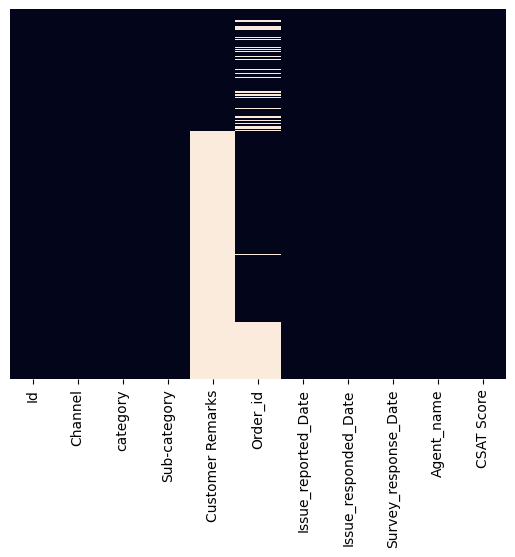

In [204]:
sns.heatmap(data_123.isnull(), yticklabels=False, cbar=False)
plt.show()

## 6. Горизонтальная интеграция: добавление данных о заказах

In [205]:
orders_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.1%20data%20integration/data/orders.csv",index_col=0)
orders_data.head()

,Id,order_date_time,Customer_City,Product_category,Item_price
0,53465d50-a568-48a9-b96e-ee2a0524fee8,14/08/2023 18:54,NEW DELHI,Books & General merchandise,144.0
1,57d64c28-e3dc-49bd-8e8a-8e24572c6b59,30/07/2023 21:43,HAJIPUR,Home,445.0
2,55d4e1bb-e148-437f-aa83-3bfbae939155,10/07/2023 21:20,HYDERABAD,LifeStyle,399.0
3,509803e9-4c15-4db4-bbe7-fc1e12b6c6cc,08/08/2023 16:40,JASPUR,Mobile,32999.0
4,5cfbe41f-ffcc-4fcf-8520-94bb61dee14e,07/08/2023 08:29,JHAJJAR,Electronics,1499.0


Переименуем столбец с идентификатором заказа для соответствия:

In [206]:
orders_data = orders_data.rename(columns={'Id': 'Order_id'})

Выполним левое внешнее соединение по Order_id:

In [207]:
data_with_orders = data_123.merge(orders_data, on='Order_id', how='left')
data_with_orders.head()

,Id,Channel,category,Sub-category,Customer Remarks,Order_id,Issue_reported_Date,Issue_responded_Date,Survey_response_Date,Agent_name,CSAT Score,order_date_time,Customer_City,Product_category,Item_price
0,8c910188-c387-4a1b-8d90-24379ec8c047,Inbound,Returns,Reverse Pickup Enquiry,Very happy,NaN,2023-08-04 19:10:00,2023-08-04 19:13:00,2023-08-04,J. Blackwell,1,NaN,NaN,NaN,NaN
1,99d5ee06-8d2a-4754-bd17-ed235c70bf33,Inbound,Returns,Return request,Thoda jalfi replacement approve kijiye mera,89e6448f-9a48-4892-a09c-b47e0d8a87fe,2023-08-18 09:11:00,2023-08-18 09:18:00,2023-08-18,M. Wilson,4,14/08/2023 00:42,NAYAGARH,Electronics,1499.0
2,336020c5-dc97-488f-8f16-ed33ed04e5fc,Inbound,Returns,Damaged,Technician not visit the RO and without visit ...,15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6,2023-08-22 07:15:00,2023-08-22 08:15:00,2023-08-22,A. Smith,5,NaN,NaN,NaN,NaN
3,22c5643c-3d54-487c-8863-c57e198a70be,Inbound,Returns,Fraudulent User,madam ne mera problem solve kar Diya hai . t...,NaN,2023-08-14 09:21:00,2023-08-14 09:27:00,2023-08-14,A. Berry,5,NaN,NaN,NaN,NaN
4,abd330a8-f3e2-4b7a-b14a-4ed35c4ec023,Inbound,Returns,Fraudulent User,Gjjjzjxgxteuhxgxe5xhxh,NaN,2023-08-03 08:18:00,2023-08-03 08:23:00,2023-08-03,S. Taylor,5,NaN,NaN,NaN,NaN


Визуализируем пропуски после присоединения заказов:

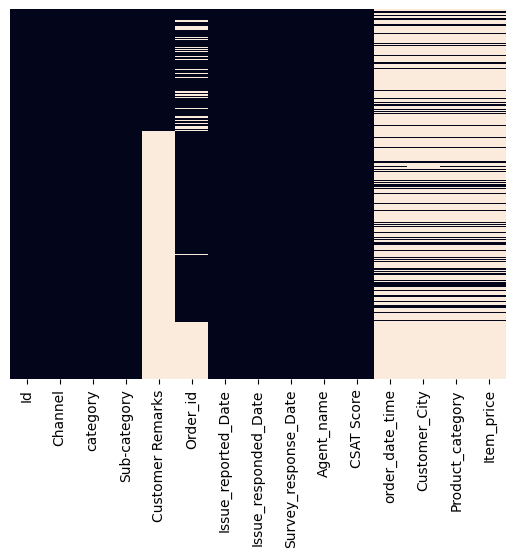

In [208]:
sns.heatmap(data_with_orders.isnull(), yticklabels=False, cbar=False)
plt.show()

## 7. Добавление данных о менеджерах

In [209]:
agent_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.1%20data%20integration/data/agents.csv",index_col=0)
agent_data.head()

,Agent,Supervisor,Manager,Tenure Bucket,Shift
0,Aaron Edwards,Mia Patel,Emily Chen,61-90,Evening
1,Aaron Romero,Mason Gupta,Jennifer Nguyen,On Job Training,Morning
2,Abigail Gonzalez,Jacob Sato,Jennifer Nguyen,On Job Training,Morning
3,Adam Barnett,Abigail Suzuki,Jennifer Nguyen,On Job Training,Morning
4,Adam Hammond,Olivia Suzuki,John Smith,31-60,Morning


Проверим уникальность имён операторов:

In [210]:
agent_data.groupby(['Agent']).agg('count').head(20)

,Supervisor,Manager,Tenure Bucket,Shift
Agent,,,,
Aaron Edwards,1,1,1,1
Aaron Romero,1,1,1,1
Abigail Gonzalez,1,1,1,1
Adam Barnett,1,1,1,1
Adam Hammond,1,1,1,1
Adam Henderson,1,1,1,1
Adam Hernandez,1,1,1,1
Adam Schwartz,1,1,1,1
Adam Torres,1,1,1,1


Преобразуем полные имена в инициалы:

In [211]:
agent_data['Agent_name'] = agent_data['Agent'].apply(
    lambda x: x.split()[0][0] + ". " + x.split()[1] if isinstance(x, str) else np.NAN
)

Проверим, что после сокращения уникальность имён потеряна:

In [212]:
agent_data.Agent_name.value_counts().head(10)

Agent_name
J. Moore       6
A. Brown       4
D. Smith       4
J. Williams    4
K. Martin      4
M. Smith       4
R. Smith       4
A. Harris      3
C. Lewis       3
C. Harris      3
Name: count, dtype: int64

Посмотрим на пример дублирования имён:

In [213]:
agent_data[agent_data.Agent_name == 'J. Moore']

,Agent,Supervisor,Manager,Tenure Bucket,Shift,Agent_name
468,Jacob Moore,Ava Wong,Jennifer Nguyen,On Job Training,Morning,J. Moore
529,Jenna Moore,Aiden Patel,John Smith,>90,Morning,J. Moore
542,Jennifer Moore,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,J. Moore
612,Jon Moore,Ava Wong,William Kim,On Job Training,Evening,J. Moore
617,Jonathan Moore,Zoe Yamamoto,John Smith,>90,Morning,J. Moore
654,Juan Moore,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,J. Moore


Посчитаем количество записей в правой таблице, соответствующих каждой строке в левой:

In [214]:
data_with_agent_numbers = data_with_orders.merge(
    agent_data.Agent_name.value_counts(), how='left', left_on='Agent_name', right_index=True
)

Выведем статистику по распределению количества строк:

In [215]:
data_with_agent_numbers["Agent_name"].value_counts()

Agent_name
D. Smith       473
W. Taylor      429
J. Williams    427
J. Smith       309
M. Castillo    301
              ... 
T. Lopez        20
W. Mueller      20
R. Gordon       20
K. Alvarado     20
B. Lyons        20
Name: count, Length: 1221, dtype: int64

Удалим данные об имени оператора у тех строк, где соответствие множественное:

In [216]:
data_with_agent_numbers = data_with_agent_numbers.drop_duplicates(subset=['Agent_name'])

Проведём корректное соединение:

In [217]:
data_with_agents = data_with_agent_numbers.merge(agent_data, how='left', on='Agent_name')
data_with_agents.info()

<class 'pandas.DataFrame'>
RangeIndex: 1371 entries, 0 to 1370
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    1371 non-null   str           
 1   Channel               1371 non-null   str           
 2   category              1371 non-null   str           
 3   Sub-category          1371 non-null   str           
 4   Customer Remarks      1371 non-null   str           
 5   Order_id              1096 non-null   str           
 6   Issue_reported_Date   1371 non-null   datetime64[us]
 7   Issue_responded_Date  1371 non-null   datetime64[us]
 8   Survey_response_Date  1371 non-null   datetime64[us]
 9   Agent_name            1371 non-null   str           
 10  CSAT Score            1371 non-null   int64         
 11  order_date_time       288 non-null    str           
 12  Customer_City         286 non-null    str           
 13  Product_category      288 non

Удалим лишние служебные столбцы:

In [218]:
data_with_agents = data_with_agents.drop(['Agent_name'], axis=1)

Визуализируем итоговые пропуски в датасете:

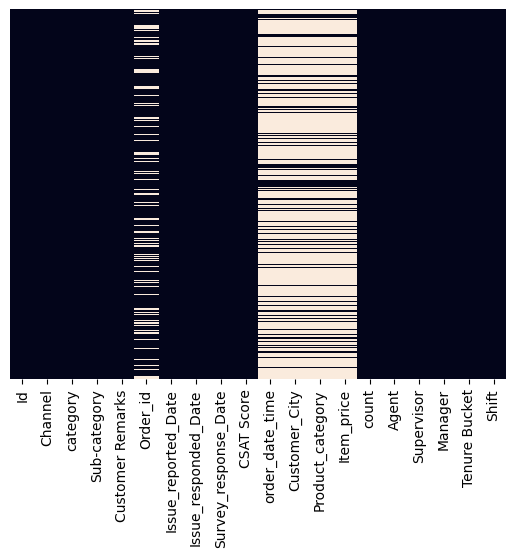

In [219]:
sns.heatmap(data_with_agents.isnull(), yticklabels=False, cbar=False)
plt.show()